In [38]:
import gzip
from pathlib import Path

import gffutils
from matplotlib_venn import venn2
import numpy as np
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy
import seaborn as sns

import torch

# phastCons distribution

In [2]:
cons_values = []

with gzip.open("/users/cn/itrujnara/genomes-project/infer_chromosome/conservation/chr21.phastCons470way.wigFix.gz") as f:
    for line in f:
        if not line.startswith(b"fixed"):
            cons_values.append(float(line))

cons_values = np.array(cons_values)

In [3]:
cons_values.shape

(37120785,)

In [4]:
cons_values.mean()

np.float64(0.05746592392914123)

<Axes: ylabel='Count'>

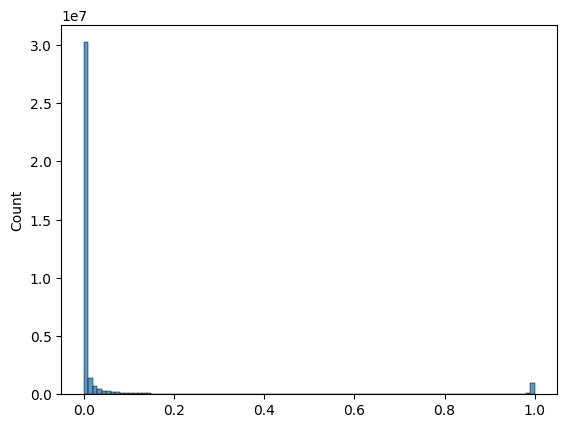

In [5]:
sns.histplot(cons_values, bins=100)

In [6]:
(cons_values > 0.75).mean()

np.float64(0.04024085158759439)

In [68]:
(cons_values == 0.).mean()

np.float64(0.6078395432639693)

# Comparison to IC

In [7]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [8]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [9]:
chunks = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_0_1048576_probs.safetensors not found
ch38_chr21_1040384_2088960_probs.safetensors not found
ch38_chr21_2080768_3129344_probs.safetensors not found
ch38_chr21_3121152_4169728_probs.safetensors not found


In [10]:
pc_start = 5010001 - 4169728
pc_end = pc_start + cons_values.shape[0]

In [12]:
probs = torch.cat(chunks)

In [17]:
ic = 2 - entropy(probs, axis=1, base=2)

In [18]:
ic_values = ic[pc_start:pc_end]

In [19]:
ic_values.shape

(37120785,)

<Axes: >

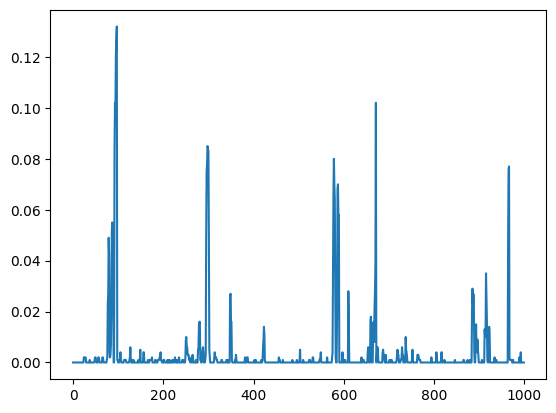

In [22]:
sns.lineplot(cons_values[100000:101000])

<Axes: >

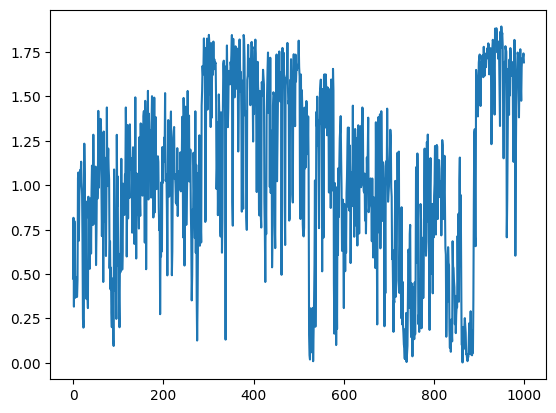

In [23]:
sns.lineplot(ic_values[100000:101000])

In [60]:
ic_quantile = np.quantile(ic_values, 0.9)
ic_quantile

np.float32(1.6620541)

In [61]:
ic_idx = np.argwhere(ic_values >= ic_quantile).flatten()
ic_idx

array([      18,       21,       25, ..., 37120241, 37120242, 37120247])

In [62]:
cons_quantile = np.quantile(cons_values, 0.9)
cons_quantile

np.float64(0.067)

In [63]:
cons_idx = np.argwhere(cons_values >= cons_quantile).flatten()
cons_idx

array([       0,        1,        2, ..., 37118611, 37118612, 37119977])

In [67]:
np.intersect1d(ic_idx, cons_idx).shape[0] / ic_idx.shape[0]

0.1296835576369272

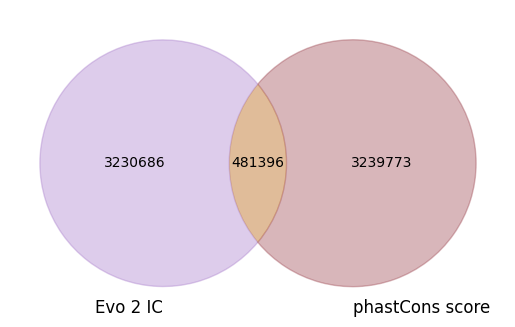

In [70]:
v = venn2((set(ic_idx), set(cons_idx)), set_labels=("Evo 2 IC", "phastCons score"))
v.get_patch_by_id("10").set_color("#AB81CD")
v.get_patch_by_id("01").set_color("#9F4A54")